In [11]:
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv

load_dotenv('.env.db', override=True)

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

DATABASE_URL = (
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require"
)

engine = create_engine(DATABASE_URL)

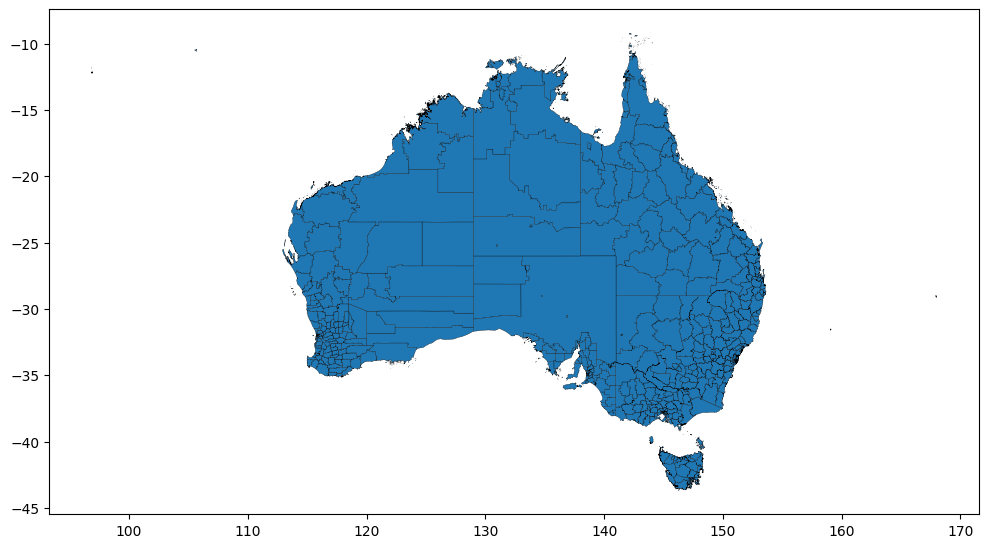

In [12]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# Load all LGAs from the database
df = pd.read_sql(
    "SELECT lga_code, lga_name, state_name, geom_wkt FROM lga_boundaries",
    engine,
)
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.GeoSeries.from_wkt(df["geom_wkt"]),
    crs="EPSG:7844",
).drop(columns=["geom_wkt"])

# Plot
gdf.plot(figsize=(12, 10), edgecolor="black", linewidth=0.2)
plt.show()

In [ ]:
m = gdf.explore()
m.save("lga_map.html")